# Day 36 (2/2) — Lasso: Key Understandings in Pictures

| # | Question |
|---|---|
| 1 | How do Lasso coefficients behave as α grows? |
| 2 | Ridge vs Lasso paths, side by side |
| 3 | **Why** does $\lvert w \rvert$ create exact zeros? (loss curve) |
| 4 | **Why**, geometrically? (the famous diamond picture) |
| 5 | Bias–variance trade-off for Lasso |

> 🎨 Most code here is *visualization only*: run it and focus on the plots.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

In [2]:
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
features = X.columns
print(X.shape)
X.head()

(442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


---
## 1. Coefficients disappear one by one

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

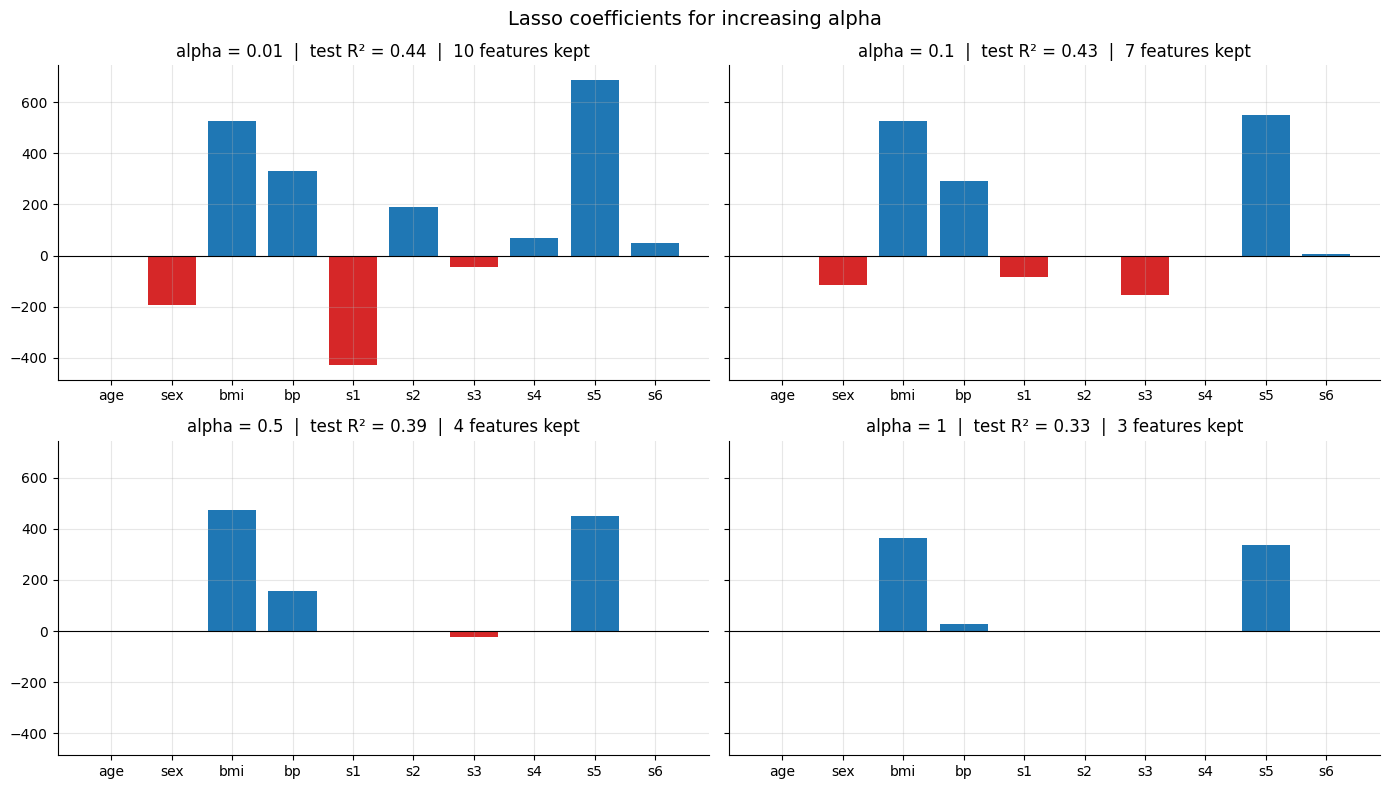

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
for ax, alpha in zip(axes.ravel(), [0.01, 0.1, 0.5, 1]):
    model = Lasso(alpha=alpha).fit(X_train, y_train)
    r2 = r2_score(y_test, model.predict(X_test))
    colors = ['lightgray' if c == 0 else ('tab:blue' if c > 0 else 'tab:red') for c in model.coef_]
    ax.bar(features, model.coef_, color=colors)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'alpha = {alpha}  |  test R² = {r2:.2f}  |  {np.sum(model.coef_ != 0)} features kept')
plt.suptitle('Lasso coefficients for increasing alpha', fontsize=14)
plt.tight_layout()
plt.show()

Compare with Ridge yesterday, where every bar shrank but stayed. Here bars **vanish**.

---
## 2. Ridge vs Lasso coefficient paths

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

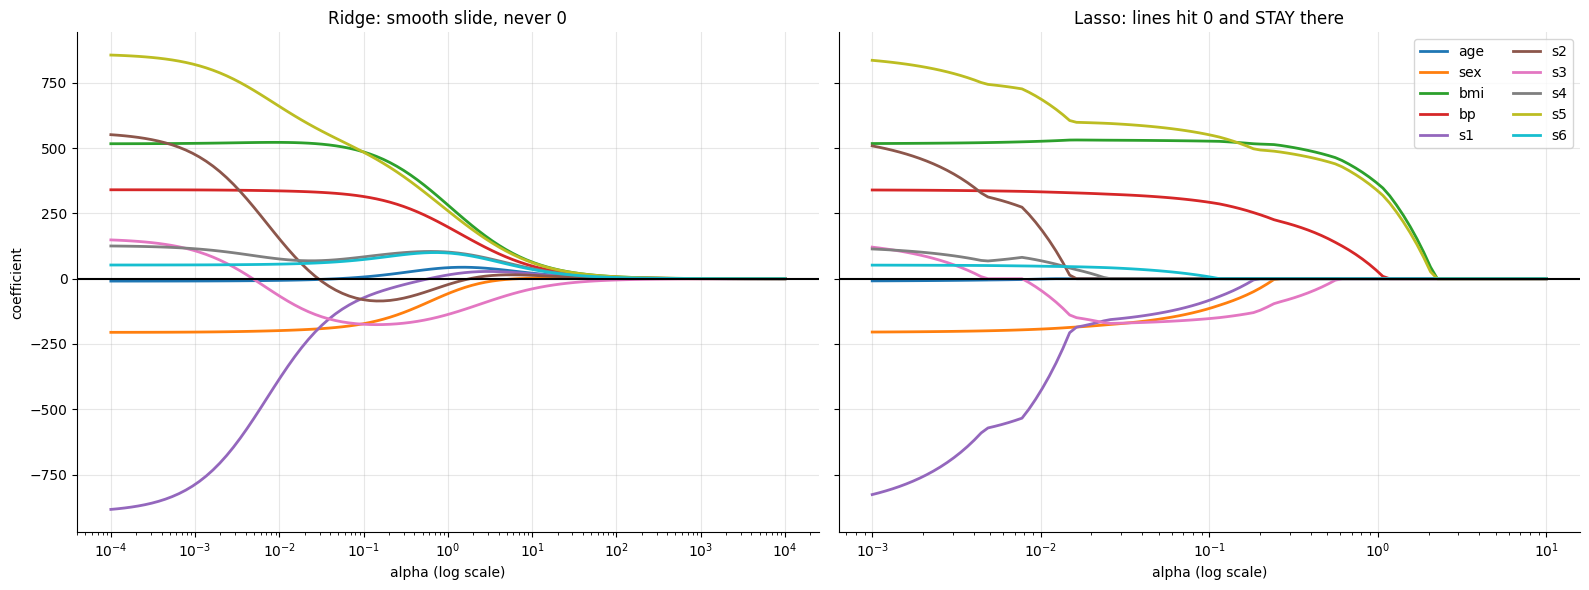

In [4]:
ridge_alphas = np.logspace(-4, 4, 100)
lasso_alphas = np.logspace(-3, 1, 100)
ridge_paths = np.array([Ridge(alpha=a).fit(X_train, y_train).coef_ for a in ridge_alphas])
lasso_paths = np.array([Lasso(alpha=a, max_iter=10000).fit(X_train, y_train).coef_ for a in lasso_alphas])

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, alphas, paths, title in [(axes[0], ridge_alphas, ridge_paths, 'Ridge: smooth slide, never 0'),
                                 (axes[1], lasso_alphas, lasso_paths, 'Lasso: lines hit 0 and STAY there')]:
    for j, name in enumerate(features):
        ax.plot(alphas, paths[:, j], linewidth=2, label=name)
    ax.axhline(0, color='black', linewidth=1.5)
    ax.set_xscale('log')
    ax.set_xlabel('alpha (log scale)')
    ax.set_title(title)
axes[0].set_ylabel('coefficient')
axes[1].legend(ncol=2)
plt.tight_layout()
plt.show()

On the right, each line drops to the zero axis at its own α and stays flat on it. The order in which features
hit zero is a **ranking of feature importance**.

---
## 3. Why exact zeros? The loss curve

One feature, intercept fixed. Loss = squared error + $\alpha\lvert m\rvert$. Dots mark the minimum of each curve.

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

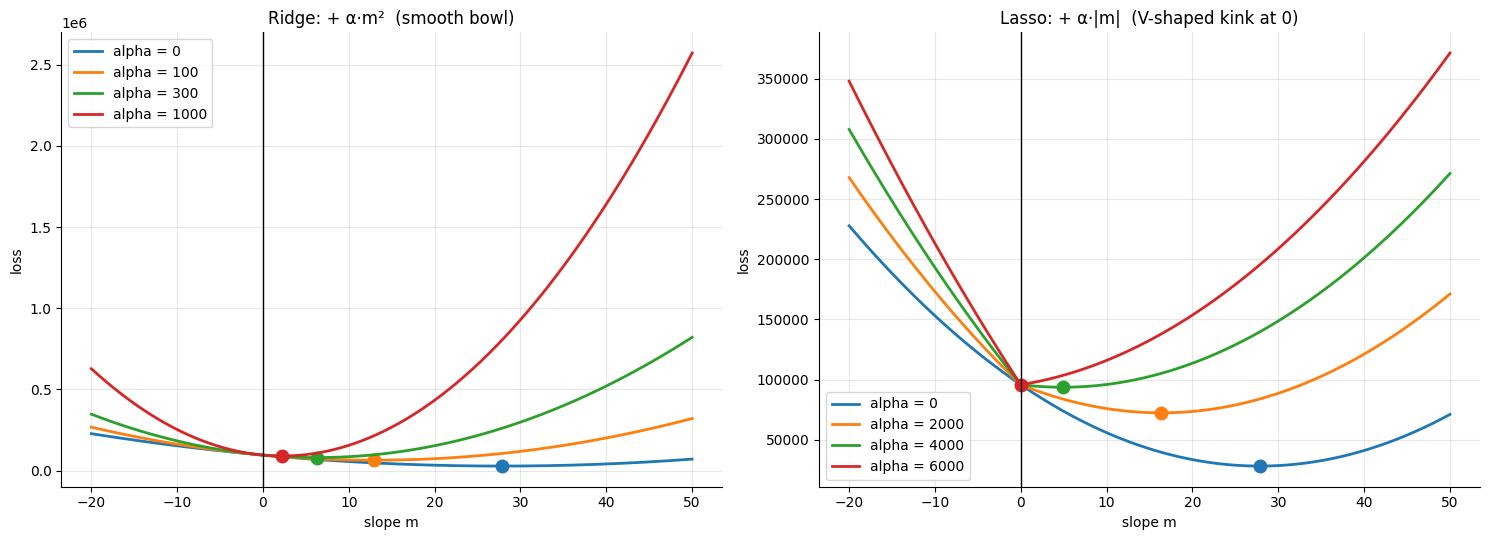

In [5]:
from sklearn.datasets import make_regression

X1, y1 = make_regression(n_samples=100, n_features=1, noise=20, random_state=13)
b = LinearRegression().fit(X1, y1).intercept_
m_values = np.linspace(-20, 50, 2001)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, penalty, alphas, title in [
        (axes[0], lambda m: m**2, [0, 100, 300, 1000], 'Ridge: + α·m²  (smooth bowl)'),
        (axes[1], np.abs, [0, 2000, 4000, 6000], 'Lasso: + α·|m|  (V-shaped kink at 0)')]:
    for alpha in alphas:
        loss = np.array([np.sum((y1 - (m * X1.ravel() + b))**2) for m in m_values]) + alpha * penalty(m_values)
        line, = ax.plot(m_values, loss, linewidth=2, label=f'alpha = {alpha}')
        ax.plot(m_values[loss.argmin()], loss.min(), 'o', color=line.get_color(), markersize=9)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('slope m')
    ax.set_ylabel('loss')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

- **Ridge (left):** $m^2$ is flat near 0, so it barely pushes small weights. The minimum creeps toward 0 but never lands on it.
- **Lasso (right):** $|m|$ has a **sharp V-shaped kink at 0** and pushes with the *same force* no matter how small $m$ is.
  Once α is large enough, the kink becomes the lowest point, and the minimum lands **exactly** on $m = 0$ (red dot).

---
## 4. Why exact zeros? The geometry

Penalised regression = minimise the error while keeping the weights inside a region:
- Ridge: $w_1^2 + w_2^2 \le t$, a **circle**
- Lasso: $\lvert w_1\rvert + \lvert w_2\rvert \le t$, a **diamond**

The solution is where the expanding error ellipse (grey) first touches the region.

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

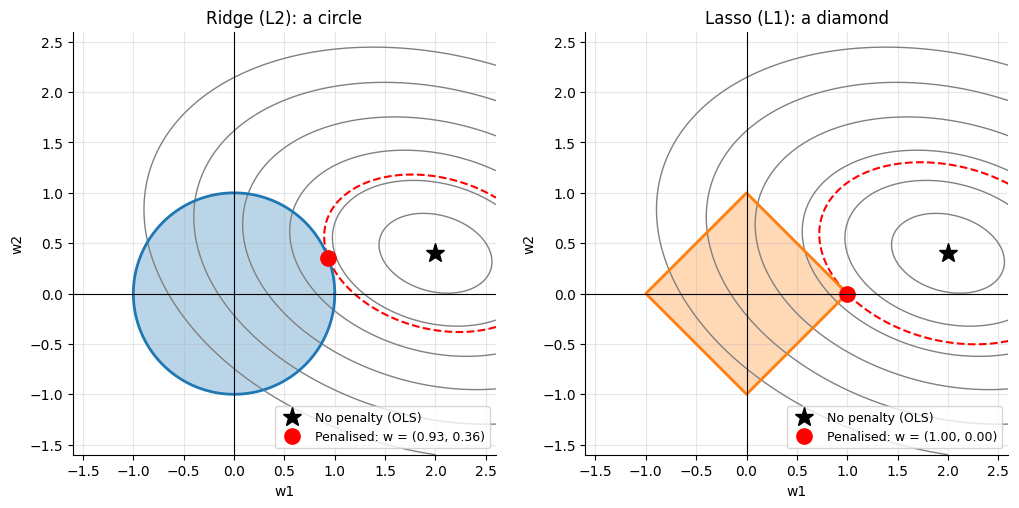

In [6]:
# A 2-feature problem: the error (RSS) surface is a bowl whose lowest point is the OLS solution
A = np.array([[1.0, 0.3], [0.3, 2.0]])
w_ols = np.array([2.0, 0.4])
rss = lambda w1, w2: (A[0, 0] * (w1 - w_ols[0])**2 + 2 * A[0, 1] * (w1 - w_ols[0]) * (w2 - w_ols[1])
                      + A[1, 1] * (w2 - w_ols[1])**2)

def boundary(radius_fn, n=4000):
    th = np.linspace(0, 2 * np.pi, n)
    d = np.c_[np.cos(th), np.sin(th)]
    r = np.array([radius_fn(v) for v in d])
    return d * r[:, None]

def best_on(points):
    return points[np.argmin(rss(points[:, 0], points[:, 1]))]

shapes = [('Ridge (L2): a circle', lambda d: 1.0, 'tab:blue'), ('Lasso (L1): a diamond', lambda d: 1.0 / (abs(d[0]) + abs(d[1])), 'tab:orange')]

g = np.linspace(-1.6, 2.6, 300)
G1, G2 = np.meshgrid(g, g)
fig, axes = plt.subplots(1, len(shapes), figsize=(5.2 * len(shapes), 5))
axes = np.atleast_1d(axes)
for ax, (name, fn, color) in zip(axes, shapes):
    pts = boundary(fn)
    w = best_on(pts)
    ax.contour(G1, G2, rss(G1, G2), levels=[0.3, 1, 2, 3.5, 5.5, 8], colors='gray', linewidths=1)
    ax.contour(G1, G2, rss(G1, G2), levels=[rss(*w)], colors='red', linestyles='--', linewidths=1.5)
    ax.fill(pts[:, 0], pts[:, 1], color=color, alpha=0.3)
    ax.plot(pts[:, 0], pts[:, 1], color=color, linewidth=2)
    ax.plot(*w_ols, 'k*', markersize=14, label='No penalty (OLS)')
    ax.plot(*w, 'o', color='red', markersize=11, label=f'Penalised: w = ({w[0]:.2f}, {w[1]:.2f})')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_aspect('equal')
    ax.set_xlim(-1.6, 2.6)
    ax.set_ylim(-1.6, 2.6)
    ax.set_xlabel('w1')
    ax.set_ylabel('w2')
    ax.set_title(name)
    ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

Same data, same ellipses:
- The **circle** is smooth, so the ellipse touches it at a general point → both weights non-zero.
- The **diamond** has **corners on the axes**, and ellipses very often hit a corner first. At a corner one weight is
  **exactly 0** (here $w_2 = 0$).

In higher dimensions the diamond has even more corners and edges lying on the axes, so Lasso zeroes out many features at once.

---
## 5. Bias–variance trade-off for Lasso

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

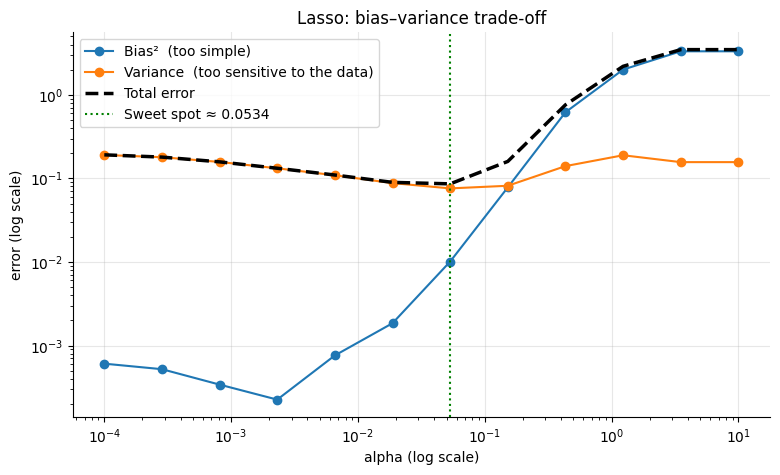

In [7]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)   # some tiny-alpha fits stop early; harmless here
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

def true_f(x):
    return 0.7 * x**2 - 2 * x + 3

x_grid = np.linspace(-1.5, 2.5, 50)
alphas_bv = np.logspace(-4, 1, 12)
bias2, variance = [], []

for a in alphas_bv:
    rng = np.random.default_rng(0)
    preds = []
    for _ in range(200):                                  # 200 different training sets
        x = rng.uniform(-2, 3, 40)
        y_noisy = true_f(x) + rng.normal(0, 1, 40)
        model = make_pipeline(PolynomialFeatures(12, include_bias=False), StandardScaler(),
                              Lasso(alpha=a, max_iter=20000))
        model.fit(x.reshape(-1, 1), y_noisy)
        preds.append(model.predict(x_grid.reshape(-1, 1)))
    preds = np.array(preds)
    bias2.append(((preds.mean(axis=0) - true_f(x_grid)) ** 2).mean())
    variance.append(preds.var(axis=0).mean())

bias2, variance = np.array(bias2), np.array(variance)
total = bias2 + variance
best = alphas_bv[total.argmin()]

plt.figure(figsize=(9, 5))
plt.plot(alphas_bv, bias2, 'o-', label='Bias²  (too simple)')
plt.plot(alphas_bv, variance, 'o-', label='Variance  (too sensitive to the data)')
plt.plot(alphas_bv, total, 'k--', linewidth=2.5, label='Total error')
plt.axvline(best, color='green', linestyle=':', label=f'Sweet spot ≈ {best:.3g}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('error (log scale)')
plt.title('Lasso: bias–variance trade-off')
plt.legend()
plt.show()

Same story as Ridge: small α means high variance, large α means high bias, and the sweet spot sits between them.

---
## Ridge vs Lasso: summary

| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penalty | $\alpha\sum w_j^2$ | $\alpha\sum \lvert w_j\rvert$ |
| Coefficients | shrink, **never exactly 0** | shrink and **become exactly 0** |
| Feature selection | ❌ | ✅ |
| Constraint shape | circle | diamond |
| Closed-form solution | ✅ | ❌ (coordinate descent) |
| Correlated features | shares weight between them | tends to keep **one** and drop the others |
| Use when | many features all contribute a little | you suspect only a few features matter |

## 🧠 Quick check

<details><summary>1. Why does the |m| penalty produce exact zeros while m² does not?</summary>

$|m|$ pushes with constant force even when $m$ is tiny, and its kink at 0 can become the minimum. $m^2$'s push fades to nothing near 0.
</details>

<details><summary>2. In the geometry picture, where does Lasso's solution land, and why does that matter?</summary>

On a corner of the diamond, which lies on an axis, so one weight is exactly 0.
</details>

<details><summary>3. Lasso's weakness with correlated features?</summary>

It picks one of the group somewhat arbitrarily and drops the rest. Elastic Net (Day 37) fixes this.
</details>

➡️ **Next day:** Elastic Net: combine Ridge and Lasso to get the best of both.